In [1]:
import torch

print("PyTorch:", torch.__version__)
print("GPU disponibile:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU disponibile: True
GPU: Tesla T4


In [2]:
%cd /content
!test -d sam2 || git clone https://github.com/facebookresearch/sam2.git

%cd /content/sam2
!pip install -q -e .

print("Commit SAM2 utilizzato:")
!git rev-parse HEAD

/content
Cloning into 'sam2'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 1107 (delta 10), reused 4 (delta 4), pack-reused 1093 (from 2)
Receiving objects: 100% (1107/1107), 134.85 MiB | 26.10 MiB/s, done.
Resolving deltas: 100% (385/385), done.
/content/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 9.6 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
Commit SAM2 utilizzato:
2b90b9f5ceec907a1c18123530e92e794ad901a4


In [3]:
%cd /content/sam2

!mkdir -p checkpoints
!wget -q --show-progress \
  -O checkpoints/sam2.1_hiera_small.pt \
  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt

!ls -lh checkpoints/sam2.1_hiera_small.pt
!sha256sum checkpoints/sam2.1_hiera_small.pt


/content/sam2
checkpoints/sam2.1_ 100%[===================>] 175.87M   219MB/s    in 0.8s    
-rw-r--r-- 1 root root 176M Sep 29  2024 checkpoints/sam2.1_hiera_small.pt
6d1aa6f30de5c92224f8172114de081d104bbd23dd9dc5c58996f0cad5dc4d38  checkpoints/sam2.1_hiera_small.pt


In [4]:
%cd /content

from google.colab import files

uploaded = files.upload()
print("File caricati:", list(uploaded))

/content


Saving san_donato_pilot_85_105.mp4 to san_donato_pilot_85_105.mp4
File caricati: ['san_donato_pilot_85_105.mp4']


FPS: 24.999
Frame estratti: 500
Primo frame: /content/san_donato_frames/00000.jpg
Ultimo frame: /content/san_donato_frames/00499.jpg


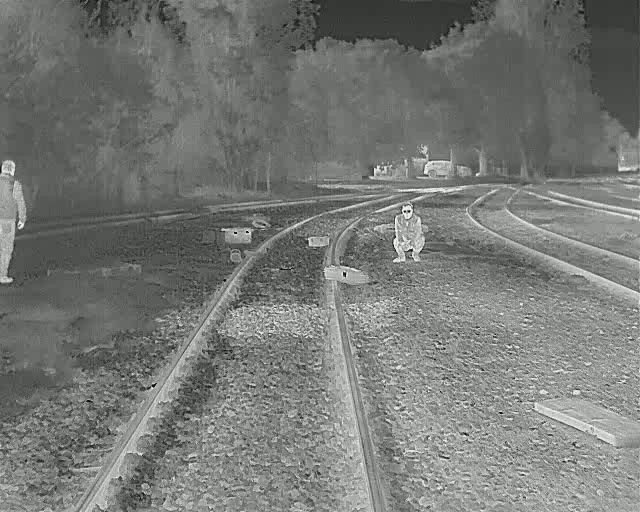

In [5]:
import cv2
import shutil
from pathlib import Path
from PIL import Image
from IPython.display import display

video_path = Path("/content/san_donato_pilot_85_105.mp4")
frames_dir = Path("/content/san_donato_frames")

if frames_dir.exists():
    shutil.rmtree(frames_dir)
frames_dir.mkdir()

cap = cv2.VideoCapture(str(video_path))
assert cap.isOpened(), "Impossibile aprire il video"

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = 0

while True:
    ok, frame = cap.read()
    if not ok:
        break

    output = frames_dir / f"{frame_count:05d}.jpg"
    cv2.imwrite(str(output), frame)
    frame_count += 1

cap.release()

print("FPS:", fps)
print("Frame estratti:", frame_count)
print("Primo frame:", frames_dir / "00000.jpg")
print("Ultimo frame:", frames_dir / f"{frame_count - 1:05d}.jpg")

display(Image.open(frames_dir / "00000.jpg"))

In [6]:
%cd /content/sam2

import torch
from sam2.build_sam import build_sam2_video_predictor

SAM2_COMMIT = "2b90b9f5ceec907a1c18123530e92e794ad901a4"
CHECKPOINT_SHA256 = "6d1aa6f30de5c92224f8172114de081d104bbd23dd9dc5c58996f0cad5dc4d38"
SOURCE_START_FRAME = 2125
CLIP_START_SECONDS = 85

checkpoint = "/content/sam2/checkpoints/sam2.1_hiera_small.pt"
model_config = "configs/sam2.1/sam2.1_hiera_s.yaml"

predictor = build_sam2_video_predictor(
    model_config,
    checkpoint,
    device="cuda",
)

inference_state = predictor.init_state(
    video_path=str(frames_dir),
    offload_video_to_cpu=True,
)

predictor.reset_state(inference_state)

print("SAM2 caricato")
print("Frame disponibili:", len(inference_state["images"]))
print("GPU:", torch.cuda.get_device_name(0))

/content/sam2


frame loading (JPEG): 100%|██████████| 500/500 [00:17<00:00, 28.78it/s]


SAM2 caricato
Frame disponibili: 500
GPU: Tesla T4


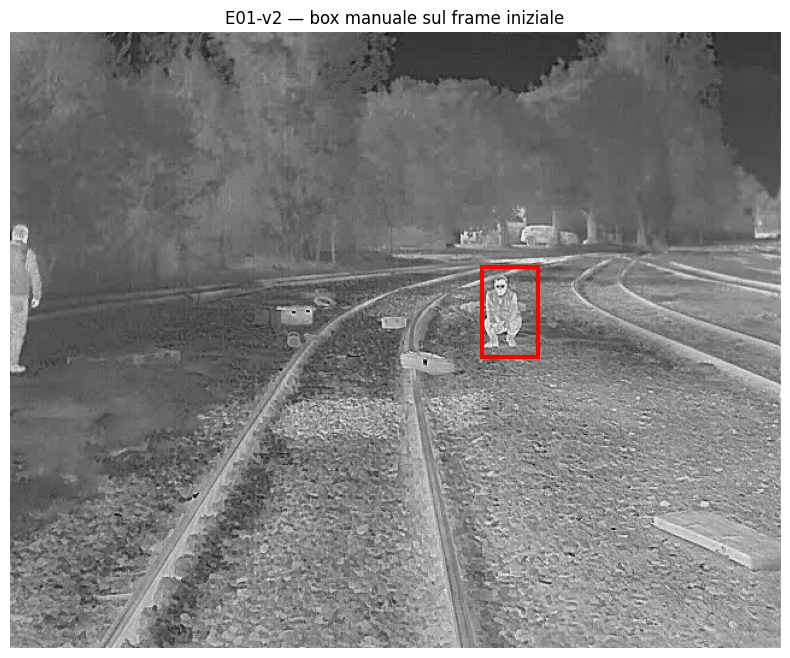

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

first_frame = np.array(
    Image.open(frames_dir / "00000.jpg").convert("RGB")
)

# Stessa box del pilot precedente, per un confronto riproducibile.
person_box = np.array(
    [392, 195, 438, 270],
    dtype=np.float32,
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(first_frame)

x1, y1, x2, y2 = person_box
ax.add_patch(
    Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        edgecolor="red",
        facecolor="none",
        linewidth=3,
    )
)

ax.set_title("E01-v2 — box manuale sul frame iniziale")
ax.axis("off")
plt.show()

/content/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/content/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


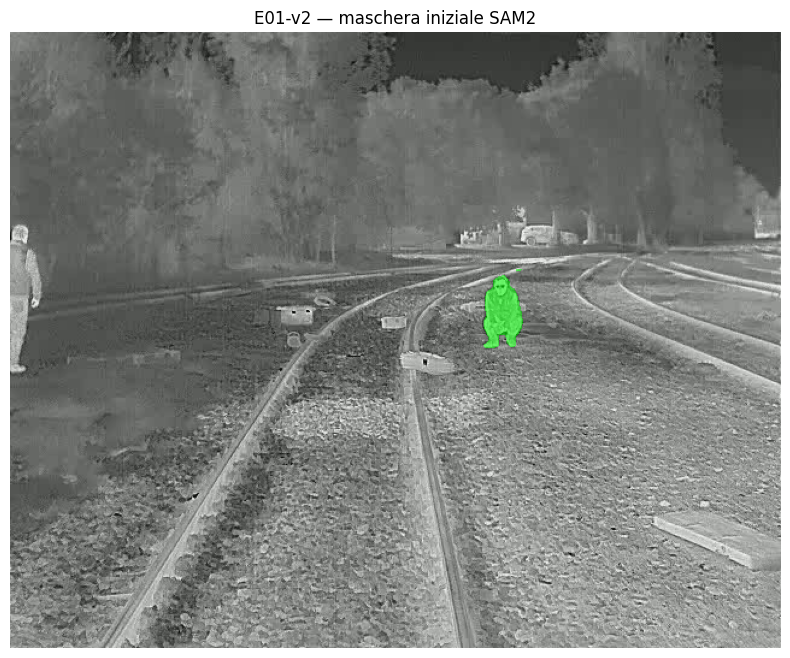

Object ID: [1]
Area maschera: 1467 pixel


In [8]:
predictor.reset_state(inference_state)

with torch.inference_mode(), torch.autocast(
    "cuda",
    dtype=torch.float16,
):
    _, object_ids, mask_logits = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=0,
        obj_id=1,
        box=person_box,
    )

initial_mask = (
    mask_logits[0] > 0
).cpu().numpy().squeeze()

overlay = np.zeros(
    (*initial_mask.shape, 4),
    dtype=np.float32,
)
overlay[initial_mask] = [0.0, 1.0, 0.0, 0.55]

plt.figure(figsize=(10, 8))
plt.imshow(first_frame)
plt.imshow(overlay)
plt.title("E01-v2 — maschera iniziale SAM2")
plt.axis("off")
plt.show()

print("Object ID:", [int(value) for value in object_ids])
print("Area maschera:", int(initial_mask.sum()), "pixel")

In [9]:
from tqdm.auto import tqdm

video_segments = {}

with torch.inference_mode(), torch.autocast(
    "cuda",
    dtype=torch.float16,
):
    propagation = predictor.propagate_in_video(inference_state)

    for (
        output_frame,
        output_object_ids,
        output_mask_logits,
    ) in tqdm(
        propagation,
        total=frame_count,
        desc="Propagazione SAM2",
    ):
        video_segments[int(output_frame)] = {
            int(object_id): (
                output_mask_logits[index] > 0
            ).cpu().numpy().squeeze()
            for index, object_id in enumerate(output_object_ids)
        }

print("Frame elaborati:", len(video_segments))
print("Primo frame disponibile:", min(video_segments))
print("Ultimo frame disponibile:", max(video_segments))

assert len(video_segments) == 500

Propagazione SAM2:   0%|          | 0/500 [00:00<?, ?it/s]


propagate in video:   0%|          | 0/500 [00:00<?, ?it/s]/content/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/content/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(

propagate in video: 100%|██████████| 500/500 [01:19<00:00,  6.31it/s]

Frame elaborati: 500
Primo frame disponibile: 0
Ultimo frame disponibile: 499


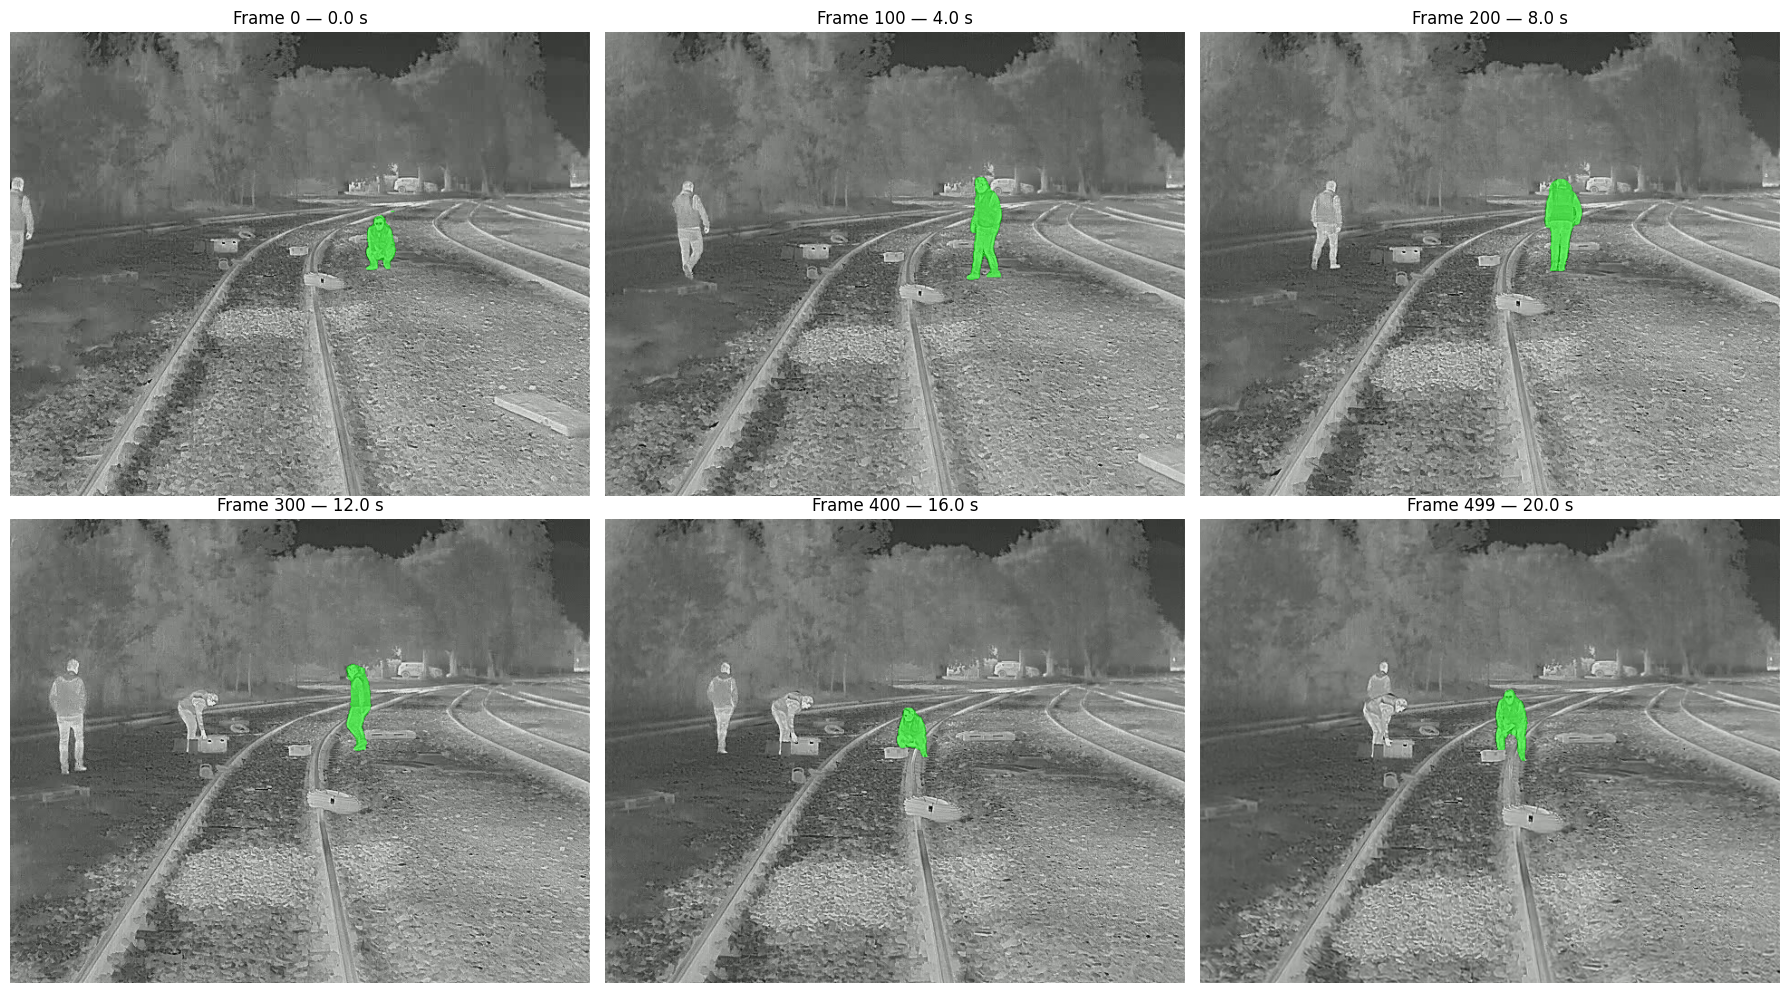

In [10]:
check_frames = [0, 100, 200, 300, 400, 499]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for axis, frame_index in zip(axes.ravel(), check_frames):
    frame = np.array(
        Image.open(
            frames_dir / f"{frame_index:05d}.jpg"
        ).convert("RGB")
    )

    mask = video_segments[frame_index][1]

    overlay = np.zeros(
        (*mask.shape, 4),
        dtype=np.float32,
    )
    overlay[mask] = [0.0, 1.0, 0.0, 0.55]

    axis.imshow(frame)
    axis.imshow(overlay)
    axis.set_title(
        f"Frame {frame_index} — {frame_index / fps:.1f} s"
    )
    axis.axis("off")

plt.tight_layout()

preview_path = "/content/E01_v2_sam2_six_frames.png"
plt.savefig(
    preview_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [11]:
%cd /content

from google.colab import files

uploaded_gt = files.upload()
print("Ground truth caricata:", list(uploaded_gt))

/content


Saving test_video_san_donato_v2_reviewed_boxes.csv to test_video_san_donato_v2_reviewed_boxes.csv
Ground truth caricata: ['test_video_san_donato_v2_reviewed_boxes.csv']


In [12]:
import pandas as pd
import numpy as np

# 1. Bounding box ricavate dalle maschere SAM2
prediction_rows = []

for clip_frame in range(frame_count):
    mask = video_segments[clip_frame][1].astype(bool)
    y_coordinates, x_coordinates = np.where(mask)

    if len(x_coordinates) == 0:
        continue

    prediction_rows.append({
        "frame": SOURCE_START_FRAME + clip_frame,
        "clip_frame": clip_frame,
        "label": "anomalia",
        "score": 1.0,
        "xtl": int(x_coordinates.min()),
        "ytl": int(y_coordinates.min()),
        "xbr": int(x_coordinates.max()) + 1,
        "ybr": int(y_coordinates.max()) + 1,
        "prompt": "manual_box_frame_0",
        "method": "sam2.1_hiera_small",
        "mask_area_pixels": int(mask.sum()),
    })

predictions = pd.DataFrame(prediction_rows)

# 2. Ground truth revisionata
gt_path = "/content/test_video_san_donato_v2_reviewed_boxes.csv"
ground_truth = pd.read_csv(gt_path)

target_track = ground_truth[
    (ground_truth["track_id"].astype(str) == "0")
    & (ground_truth["outside"].astype(int) == 0)
    & (ground_truth["frame"] >= SOURCE_START_FRAME)
    & (ground_truth["frame"] < SOURCE_START_FRAME + frame_count)
].copy()

print("Predizioni SAM2:", len(predictions))
print(
    "Ground truth track 0:",
    len(target_track),
    "frame",
    target_track["frame"].min(),
    "→",
    target_track["frame"].max(),
)

# 3. Confronto sui frame comuni
common = predictions.merge(
    target_track[
        ["frame", "xtl", "ytl", "xbr", "ybr"]
    ],
    on="frame",
    suffixes=("_pred", "_gt"),
)

def box_iou(row):
    intersection_x1 = max(row.xtl_pred, row.xtl_gt)
    intersection_y1 = max(row.ytl_pred, row.ytl_gt)
    intersection_x2 = min(row.xbr_pred, row.xbr_gt)
    intersection_y2 = min(row.ybr_pred, row.ybr_gt)

    intersection = max(
        0,
        intersection_x2 - intersection_x1,
    ) * max(
        0,
        intersection_y2 - intersection_y1,
    )

    prediction_area = (
        row.xbr_pred - row.xtl_pred
    ) * (
        row.ybr_pred - row.ytl_pred
    )

    ground_truth_area = (
        row.xbr_gt - row.xtl_gt
    ) * (
        row.ybr_gt - row.ytl_gt
    )

    union = prediction_area + ground_truth_area - intersection

    return intersection / union if union > 0 else 0.0

common["iou"] = common.apply(box_iou, axis=1)

# 4. Riepilogo
summary_rows = []

for threshold in [0.3, 0.5]:
    true_positives = int((common["iou"] >= threshold).sum())
    failures = len(common) - true_positives

    summary_rows.append({
        "scope": "target_track_common_interval",
        "gt_track_id": 0,
        "frames": len(common),
        "iou_threshold": threshold,
        "tp": true_positives,
        "fp": failures,
        "fn": failures,
        "precision": true_positives / len(common),
        "recall": true_positives / len(common),
        "f1": true_positives / len(common),
        "mean_iou": common["iou"].mean(),
        "median_iou": common["iou"].median(),
        "min_iou": common["iou"].min(),
        "max_iou": common["iou"].max(),
    })

summary = pd.DataFrame(summary_rows)

display(summary)

Predizioni SAM2: 500
Ground truth track 0: 490 frame 2135 → 2624


,scope,gt_track_id,frames,iou_threshold,tp,fp,fn,precision,recall,f1,mean_iou,median_iou,min_iou,max_iou
0,target_track_common_interval,0,490,0.3,490,0,0,1.0,1.0,1.0,0.755025,0.76892,0.560938,0.981267
1,target_track_common_interval,0,490,0.5,490,0,0,1.0,1.0,1.0,0.755025,0.76892,0.560938,0.981267


In [13]:
import cv2
from tqdm.auto import tqdm

temporary_video = "/content/E01_v2_overlay_mp4v.mp4"
final_video = "/content/E01_v2_sam2_overlay_h264.mp4"

first_image = cv2.imread(
    str(frames_dir / "00000.jpg")
)
height, width = first_image.shape[:2]

writer = cv2.VideoWriter(
    temporary_video,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height),
)

for frame_index in tqdm(
    range(frame_count),
    desc="Creazione video E01-v2",
):
    frame = cv2.imread(
        str(frames_dir / f"{frame_index:05d}.jpg")
    )

    mask = video_segments[frame_index][1].astype(bool)

    green = np.array(
        [0, 255, 0],
        dtype=np.float32,
    )

    frame[mask] = (
        0.45 * frame[mask].astype(np.float32)
        + 0.55 * green
    ).astype(np.uint8)

    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    cv2.drawContours(
        frame,
        contours,
        -1,
        (0, 255, 0),
        2,
    )

    cv2.putText(
        frame,
        "E01-v2 SAM2 - manual box prompt",
        (15, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (0, 255, 0),
        2,
    )

    writer.write(frame)

writer.release()

!ffmpeg -y -loglevel error \
  -i /content/E01_v2_overlay_mp4v.mp4 \
  -c:v libx264 \
  -preset fast \
  -crf 20 \
  -pix_fmt yuv420p \
  -movflags +faststart \
  /content/E01_v2_sam2_overlay_h264.mp4

!ls -lh /content/E01_v2_sam2_overlay_h264.mp4

Creazione video E01-v2:   0%|          | 0/500 [00:00<?, ?it/s]

-rw-r--r-- 1 root root 6.9M Jul  4 19:26 /content/E01_v2_sam2_overlay_h264.mp4


In [15]:
import json
import shutil
from pathlib import Path
from datetime import datetime, timezone

output_dir = Path("/content/E01_v2_results")

if output_dir.exists():
    shutil.rmtree(output_dir)
output_dir.mkdir()

# File tabellari
predictions.to_csv(
    output_dir / "predictions_boxes.csv",
    index=False,
)

common.to_csv(
    output_dir / "per_frame_iou.csv",
    index=False,
)

summary.to_csv(
    output_dir / "summary.csv",
    index=False,
)

target_track.to_csv(
    output_dir / "ground_truth_track_0.csv",
    index=False,
)

# Maschere
all_masks = np.stack([
    video_segments[index][1].astype(np.uint8)
    for index in range(frame_count)
])

np.savez_compressed(
    output_dir / "sam2_masks.npz",
    masks=all_masks,
    source_frames=np.arange(
        SOURCE_START_FRAME,
        SOURCE_START_FRAME + frame_count,
    ),
)

# Metadati
metadata = {
    "experiment_id": "E01_v2_sam2_manual_box",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "source_video": "test_video_san_donato.mp4",
    "clip_seconds": [85, 105],
    "source_start_frame": SOURCE_START_FRAME,
    "clip_frames": frame_count,
    "source_fps": float(fps),
    "model": "SAM 2.1",
    "checkpoint": "sam2.1_hiera_small.pt",
    "sam2_commit": SAM2_COMMIT,
    "checkpoint_sha256": CHECKPOINT_SHA256,
    "hardware": torch.cuda.get_device_name(0),
    "prompt_type": "manual_box",
    "prompt_frame": 0,
    "prompt_box": person_box.tolist(),
    "object_id": 1,
    "fine_tuning": False,
    "ground_truth_version": "test_video_san_donato_v2_reviewed",
    "ground_truth_track_id": 0,
    "evaluated_common_frames": int(len(common)),
    "excluded_initial_frames_without_gt": 10,
    "mean_iou": float(common["iou"].mean()),
    "median_iou": float(common["iou"].median()),
    "min_iou": float(common["iou"].min()),
    "max_iou": float(common["iou"].max()),
    "f1_iou_03": float(
        summary.loc[
            summary["iou_threshold"] == 0.3,
            "f1",
        ].iloc[0]
    ),
    "f1_iou_05": float(
        summary.loc[
            summary["iou_threshold"] == 0.5,
            "f1",
        ].iloc[0]
    ),
    "interpretation": (
        "Segmentazione e tracking condizionati da una box manuale; "
        "non e anomaly detection autonoma."
    ),
}

with open(
    output_dir / "metadata.json",
    "w",
    encoding="utf-8",
) as handle:
    json.dump(
        metadata,
        handle,
        indent=2,
        ensure_ascii=False,
    )

# Figure e video
shutil.copy(
    "/content/E01_v2_sam2_six_frames.png",
    output_dir / "six_frames.png",
)

shutil.copy(
    "/content/E01_v2_sam2_overlay_h264.mp4",
    output_dir / "sam2_overlay.mp4",
)

# Archivio ZIP
zip_path = shutil.make_archive(
    "/content/E01_v2_sam2_manual_box_results",
    "zip",
    output_dir,
)

print("Pacchetto creato:", zip_path)
print("Dimensione:", Path(zip_path).stat().st_size / 1024**2, "MB")

files.download(zip_path)

Pacchetto creato: /content/E01_v2_sam2_manual_box_results.zip
Dimensione: 10.608980178833008 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>